# Notebook 06 - Deep Learning Model

This notebook trains a Deep Learning model using TensorFlow and Keras for intent classification.

In [14]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

import pickle

In [17]:
intents = pd.read_csv("../data/intents_clean.csv")

In [4]:
intents.head()

,text,intent,response
0,catch later,goodbye,Response for goodbye.
1,hi,greeting,Response for greeting.
2,good morning,greeting,Response for greeting.
3,cost redmi note 14,price_query,Response for price_query.
4,availability galaxy s24,availability,Response for availability.


In [18]:
X = intents["text"]

y = intents["intent"]

In [19]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [20]:
y = to_categorical(y)

In [21]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(X)

In [22]:
X = tokenizer.texts_to_sequences(X)

In [23]:
print(X[:5])

[[55, 56], [36], [23, 30], [31, 7, 8, 2], [72, 9, 10]]


In [24]:
max_length = 20

X = pad_sequences(

X,

maxlen=max_length,

padding="post"

)

In [25]:
X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

random_state=42

)

In [26]:
vocab_size = len(tokenizer.word_index)+1

print(vocab_size)

78


In [27]:
model = Sequential()

In [28]:
model.add(

Embedding(

input_dim=vocab_size,

output_dim=128,

input_length=max_length

)

)

c:\Users\jayas\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
model.add(

LSTM(64)

)

In [30]:
model.add(

Dropout(0.5)

)

In [31]:
model.add(

Dense(

64,

activation="relu"

)

)

In [32]:
model.add(

Dense(

y.shape[1],

activation="softmax"

)

)

In [33]:
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

In [34]:
history = model.fit(

X_train,

y_train,

epochs=20,

batch_size=32,

validation_split=0.2

)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0969 - loss: 2.3064 - val_accuracy: 0.1187 - val_loss: 2.2976
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1219 - loss: 2.3000 - val_accuracy: 0.1500 - val_loss: 2.2921
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1750 - loss: 2.1855 - val_accuracy: 0.2000 - val_loss: 1.9336
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1906 - loss: 1.9405 - val_accuracy: 0.2812 - val_loss: 1.8868
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2375 - loss: 1.8629 - val_accuracy: 0.1813 - val_loss: 1.7603
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2719 - loss: 1.6438 - val_accuracy: 0.4313 - val_loss: 1.4397
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3781 - loss: 1.3803 - val_accuracy: 0.5750 - val_loss: 1.2723
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4313 - loss: 1.1887 - val_accuracy: 0.5625 - v

In [35]:
loss,accuracy=model.evaluate(

X_test,

y_test

)

print("Accuracy :",accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9050 - loss: 0.2772  
Accuracy : 0.9049999713897705


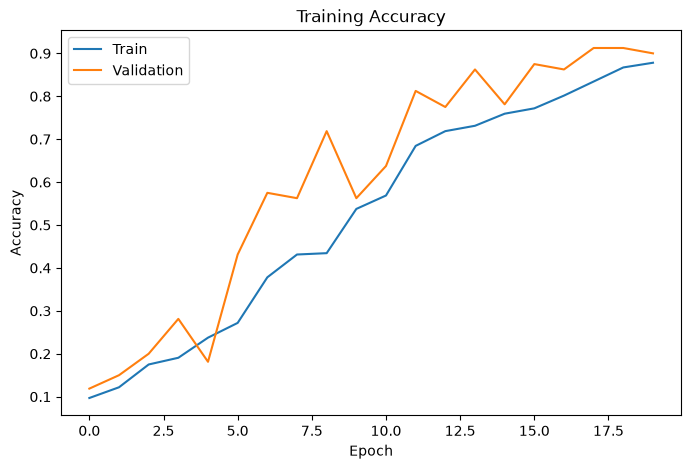

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

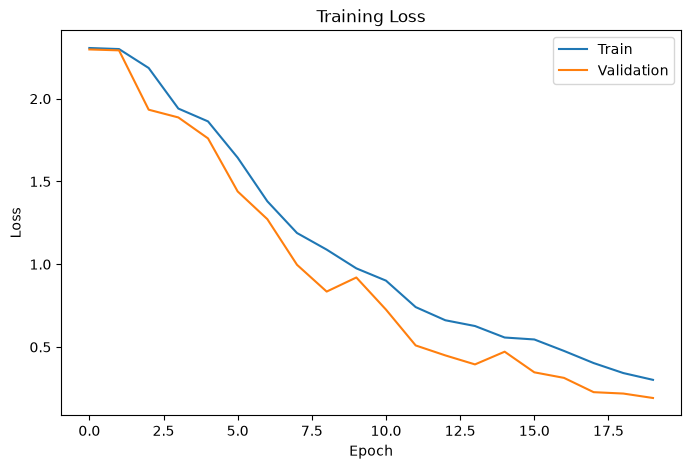

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [38]:
sentence = ["show samsung phones"]

In [39]:
sequence = tokenizer.texts_to_sequences(sentence)

sequence = pad_sequences(

sequence,

maxlen=max_length,

padding="post"

)

In [40]:
prediction = model.predict(sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


In [41]:
predicted = np.argmax(prediction)

In [42]:
print(

encoder.inverse_transform(

[predicted]

)

)

['phone_search']


In [43]:
sentence = ["show samsung phones"]

seq = tokenizer.texts_to_sequences(sentence)

seq = pad_sequences(
    seq,
    maxlen=50,
    padding='post'
)

prediction = model.predict(seq)

intent_id = prediction.argmax()

intent = encoder.inverse_transform([intent_id])

print("User:", sentence[0])
print("Predicted Intent:", intent[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
User: show samsung phones
Predicted Intent: greeting


In [44]:
intents['intent'].value_counts()

intent
accessory_search    114
price_query         107
payment             106
comparison          101
goodbye             100
greeting             99
recommendation       96
thanks               95
phone_search         94
availability         88
Name: count, dtype: int64

In [33]:
model.save(

"../models/lstm_intent_model.keras"

)

In [46]:
pickle.dump(

tokenizer,

open("../models/tokenizer.pkl","wb")

)

In [47]:
pickle.dump(

encoder,

open("../models/dl_label_encoder.pkl","wb")

)

In [48]:
print("Deep Learning Model Saved Successfully!")

Deep Learning Model Saved Successfully!


In [49]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [50]:
model = Sequential()

model.add(
    Input(shape=(max_length,))
)

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    )
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dense(
        y.shape[1],
        activation="softmax"
    )
)

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 128)        │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,202 (250.79 KB)

 Trainable params: 64,202 (250.79 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [53]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.1234 - loss: 2.3059 - val_accuracy: 0.0875 - val_loss: 2.3035
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1000 - loss: 2.3011 - val_accuracy: 0.0875 - val_loss: 2.3014
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0891 - loss: 2.3054 - val_accuracy: 0.1187 - val_loss: 2.2974
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1219 - loss: 2.2878 - val_accuracy: 0.2188 - val_loss: 2.2266
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1953 - loss: 2.0259 - val_accuracy: 0.1937 - val_loss: 1.7637
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2406 - loss: 1.7188 - val_accuracy: 0.2188 - val_loss: 1.5599
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3562 - loss: 1.4645 - val_accuracy: 0.5500 - val_loss: 1.2065
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4766 - loss: 1.1800 - val_accuracy: 0.6625 - v

In [54]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7800 - loss: 0.8245  
Accuracy: 0.7799999713897705
